# Section 2 Assignment - Automatic Text Generation

**Student Name:** Stephen White<br>
**Student ID:** 13159178

In [1]:
import torch
import copy
import gc
import transformers
from transformers import AutoModelForCausalLM, AutoProcessor, AutoTokenizer, GenerationConfig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import OrderedDict

/home/stephen-white/.pyenv/versions/3.14.3/envs/mn5162/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(transformers.__version__)

5.5.0


In [3]:
pd.set_option('display.max_colwidth', None)

In [4]:
MAX_NEW_TOKENS = 1024

In [5]:
def get_device(prefer_cuda=True, index=0):
    cuda_ok = torch.cuda.is_available()

    if prefer_cuda and cuda_ok:
        gpu_count = torch.cuda.device_count()
        if index >= gpu_count:
            raise ValueError(f"Requested cuda:{index}, but only {gpu_count} GPU(s) are available.")

        device = torch.device(f"cuda:{index}")
        torch.cuda.set_device(index)

        info = {
            "device": device,
            "device_type": "cuda",
            "device_index": index,
            "gpu_count": gpu_count,
            "gpu_name": torch.cuda.get_device_name(index),
            "current_device": torch.cuda.current_device(),
        }
    else:
        device = torch.device("cpu")
        info = {
            "device": device,
            "device_type": "cpu",
            "device_index": None,
            "gpu_count": torch.cuda.device_count() if cuda_ok else 0,
            "gpu_name": None,
            "current_device": None,
        }

    return info

In [6]:
get_device()

{'device': device(type='cuda', index=0),
 'device_type': 'cuda',
 'device_index': 0,
 'gpu_count': 1,
 'gpu_name': 'NVIDIA GeForce RTX 3060',
 'current_device': 0}

In [7]:
torch.manual_seed(2008);

In [8]:
prompts = [
    "The Implications of Recent Developments in Artificial Intelligence.",
    "The recent advancements in artificial intelligence (AI) have "
]

In [9]:
def cuda_report(device="cuda:0"):
    d = torch.device(device)
    free, total = torch.cuda.mem_get_info(d)
    return {
        "allocated_gb": round(torch.cuda.memory_allocated(d) / 1024**3,2),
        "reserved_gb": round(torch.cuda.memory_reserved(d) / 1024**3,2),
        "max_allocated_gb": round(torch.cuda.max_memory_allocated(d) / 1024**3,2),
        "max_reserved_gb": round(torch.cuda.max_memory_reserved(d) / 1024**3,2),
        "free_gb": round(free / 1024**3,2),
        "total_gb": round(total / 1024**3,2),
        "used_gb": round((total - free) / 1024**3,2)
    }

In [10]:
cuda_report()

{'allocated_gb': 0.0,
 'reserved_gb': 0.0,
 'max_allocated_gb': 0.0,
 'max_reserved_gb': 0.0,
 'free_gb': 10.91,
 'total_gb': 11.62,
 'used_gb': 0.72}

In [11]:
def unload_everything(models_dict):
    models_dict.clear()

    for name in [
        "model", "tokenizer", "input_ids", "inputs",
        "output", "outputs", "log_probs_from_logits", "iterations",
        "next_token_logits","next_token_probs", "sorted_ids", "sorted_logits",
        "probs", "logits", "token_id", "token_prob",
        "bundle", "processor", "models", "response",
    ]:
        if name in globals().keys():
            del globals()[name]
    
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    return(cuda_report())

## Models

In [12]:
models = OrderedDict()
model_paths = ["openai-community/gpt2", "Qwen/Qwen2.5-1.5B", "unsloth/Meta-Llama-3.1-8B-bnb-4bit"]

In [13]:
def get_max_supported_context(model):
    conf = model.config
    max_ctx = getattr(conf, "max_position_embeddings", None)
    if max_ctx is None:
        max_ctx = getattr(conf, "max_seq_len", None)
    if max_ctx is None:
        max_ctx = getattr(conf, "max_sequence_length", None)
    
    return max_ctx

In [14]:
def load_models(use_processor=False, return_context_len=True):
    for path in model_paths:
        print(f"Loading: {path}")
        start = time.perf_counter()
        model = AutoModelForCausalLM.from_pretrained(
            path,
            dtype="auto",
            device_map="auto"
        )
        if use_processor:
            processor = AutoProcessor.from_pretrained(path)
            models[path] = {"model": model, "processor": processor}
        else:
            tokenizer = AutoTokenizer.from_pretrained(path)
            models[path] = {"model": model, "tokenizer": tokenizer}
        dt = time.perf_counter() - start
        print(f"Loaded {path} in {dt:.2f}s")

        if return_context_len:
            max_context = get_max_supported_context(model)
            models[path]['max_context'] = int(max_context)
            print(f"Max supported context length: {max_context}\n")

    return(cuda_report())

In [15]:
load_models()

Loading: openai-community/gpt2


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 2174.23it/s]


Loaded openai-community/gpt2 in 1.08s
Max supported context length: 1024

Loading: Qwen/Qwen2.5-1.5B


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 338/338 [00:00<00:00, 1067.96it/s]


Loaded Qwen/Qwen2.5-1.5B in 1.60s
Max supported context length: 131072

Loading: unsloth/Meta-Llama-3.1-8B-bnb-4bit


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 291/291 [00:00<00:00, 449.53it/s]


Loaded unsloth/Meta-Llama-3.1-8B-bnb-4bit in 4.00s
Max supported context length: 131072



{'allocated_gb': 8.65,
 'reserved_gb': 8.66,
 'max_allocated_gb': 8.65,
 'max_reserved_gb': 8.66,
 'free_gb': 2.26,
 'total_gb': 11.62,
 'used_gb': 9.36}

In [16]:
test_txt = 'Advancements in AI have'
n_steps = 5
choices_per_step = 5

for model_name, bundle in models.items():
    print(f"Model: {model_name}")
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    input_ids = tokenizer(test_txt, return_tensors='pt')['input_ids'].to(model.device)

    iterations = []
    with torch.no_grad():
        for _ in range(n_steps):
            iteration = dict()
            iteration["Input"] = tokenizer.decode(input_ids[0])
            output = model(input_ids=input_ids)
            # Select logits of the first batch and the last token and apply softmax
            next_token_logits = output.logits[0, -1, :]
            next_token_probs = torch.softmax(next_token_logits, dim=-1)
            sorted_ids = torch.argsort(next_token_probs, dim=-1, descending=True)
            # Store tokens with highest probabilities
            for choice_idx in range(choices_per_step):
                token_id = sorted_ids[choice_idx]
                token_prob = next_token_probs[token_id].detach().float().cpu().numpy()
                token_choice = (
                    f"{tokenizer.decode(token_id)} ({100 * token_prob:.2f}%)"
                )
                iteration[f"Choice {choice_idx+1}"] = token_choice
            # Append predicted next token to input
            input_ids = torch.cat([input_ids, sorted_ids[None, 0, None]], dim=-1)
            iterations.append(iteration)
            display(pd.DataFrame(iterations).tail(1))
    print('\n')

Model: openai-community/gpt2


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
0,Advancements in AI have,been (17.16%),made (5.71%),led (4.95%),also (3.25%),allowed (3.12%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
1,Advancements in AI have been,made (11.90%),a (3.10%),shown (2.34%),very (1.26%),slow (1.08%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
2,Advancements in AI have been made,to (23.55%),in (13.28%),", (12.06%)",. (6.16%),by (5.93%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
3,Advancements in AI have been made to,the (14.14%),improve (4.05%),AI (3.25%),help (3.07%),allow (2.38%)


...

,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
0,<|begin_of_text|>Advancements in AI have,been (9.62%),led (9.62%),made (6.64%),enabled (4.00%),brought (3.76%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
1,<|begin_of_text|>Advancements in AI have been,a (5.30%),making (3.02%),rapid (2.08%),so (1.95%),the (1.83%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
2,<|begin_of_text|>Advancements in AI have been a,boon (17.87%),game (10.84%),major (8.45%),hot (6.59%),key (3.98%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
3,<|begin_of_text|>Advancements in AI have been a boon,for (54.30%),to (42.19%),in (1.64%),not (0.47%),and (0.42%)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
4,<|begin_of_text|>Advancements in AI have been a boon for,the (18.95%),many (6.98%),businesses (4.49%),marketers (2.26%),humanity (1.99%)


### Greedy Search Decoding

In [17]:
for model_name, bundle in models.items():
    print("="*100)
    
    model = bundle['model']
    tokenizer = bundle['tokenizer']
    
    print(f"Model: {model_name}. Default generation config:\n{model.generation_config}")
    print('='*100 +'\n')

    for prompt in prompts:
        print(f"Prompt: {prompt}")
        print("-"*100)
        input_ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(model.device)
        input_len = input_ids.shape[-1]

        if input_len + MAX_NEW_TOKENS > bundle['max_context']:
            allowed_new = bundle['max_context'] - input_len
        else:
            allowed_new = MAX_NEW_TOKENS
            
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)
        
        torch.cuda.synchronize()
        starter.record()
        output = model.generate(input_ids, max_new_tokens=allowed_new, do_sample=False)
        ender.record()
        torch.cuda.synchronize()
    
        elapsed = starter.elapsed_time(ender) / 1000
        
        print(tokenizer.decode(output[0]))
        print(f"\nGenerate time: {elapsed:.2f}s")
        print('\n')

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Model: openai-community/gpt2. Default generation config:
GenerationConfig {
  "bos_token_id": 50256,
  "eos_token_id": 50256
}


Prompt: The Implications of Recent Developments in Artificial Intelligence.
----------------------------------------------------------------------------------------------------


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Developments in Artificial Intelligence.

The Implications of Recent Develop

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


...

The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artif

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The recent advancements in artificial intelligence (AI) have  ____1____ the world. The AI revolution is here, and it is changing the way we live, work, and interact with each other. AI is transforming industries, from healthcare to finance, from transportation to entertainment. It is also changing the way we think about the future of work, and the way we approach education. In this article, we will explore the impact of AI on the future of work, education, and society as a whole. We will also discuss the ethical and social implications of AI, and how we can ensure that it is used in a responsible and ethical manner.  ____2____ AI is transforming the way we work, and it is changing the nature of jobs. AI is already being used in many industries, from manufacturing to healthcare, to automate tasks and improve efficiency. This has led to the creation of new jobs, such as data scientists, AI engineers, and machine learning specialists. However, it has also led to the displacement of many j

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|begin_of_text|>The Implications of Recent Developments in Artificial Intelligence. A Report of the 2018 AAAI Fall Symposium
The Implications of Recent Developments in Artificial Intelligence. A Report of the 2018 AAAI Fall Symposium
The Implications of Recent Developments in Artificial Intelligence. A Report of the 2018 AAAI Fall Symposium
The Implications of Recent Developments in Artificial Intelligence. A Report of the 2018 AAAI Fall Symposium
The Implications of Recent Developments in Artificial Intelligence. A Report of the 2018 AAAI Fall Symposium
The Implications of Recent Developments in Artificial Intelligence. A Report of the 2018 AAAI Fall Symposium
The Implications of Recent Developments in Artificial Intelligence. A Report of the 2018 AAAI Fall Symposium
The Implications of Recent Developments in Artificial Intelligence. A Report of the 2018 AAAI Fall Symposium
The Implications of Recent Developments in Artificial Intelligence. A Report of the 2018 AAAI Fall Symposium
Th

Greedy decoding always selects the highest probability next token at each step. While computationally efficient, as evidenced by shorted generation times, the flawed repetitive nature is immediately apparent. The prompt is reproduced on loop in the worst example of that. In the absence of diversity, the model cannot move away from that pattern. It is not suitable in this instance. Despite this, there is a marked improvement with an increase in model complexity, as well as in the generation from the second prompt.

### Beam Search Decoding

In [18]:
def log_probs_from_logits(logits, labels):
    logp = torch.nn.functional.log_softmax(logits, dim=-1)
    logp_label = torch.gather(logp, 2, labels.unsqueeze(2)).squeeze(-1)
    return logp_label

In [19]:
def sequence_logprob(model, labels, input_len=0):
    with torch.no_grad():
        output = model(labels)
        log_probs = log_probs_from_logits(
            output.logits[:, :-1, :], labels[:, 1:])
        seq_log_prob = torch.sum(log_probs[:, input_len:])
    return seq_log_prob.detach().float().cpu().numpy()

In [20]:
for model_name, bundle in models.items():
    print("="*100)
    print(f"Model: {model_name}. Default generation config:\n{model.generation_config}")
    
    model = bundle['model']
    tokenizer = bundle['tokenizer']

    print('='*100 +'\n')
    
    for prompt in prompts:
        print(f"Prompt: {prompt}")
        print("-"*100)
        input_ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(model.device)
        input_len = input_ids.shape[-1]
    
        if input_len + MAX_NEW_TOKENS > bundle['max_context']:
            allowed_new = bundle['max_context'] - input_len
        else:
            allowed_new = MAX_NEW_TOKENS
    
        for beams in [3, 4, 5]:
            print(f"num_beams: {beams}")
            print('-'*100)
            starter = torch.cuda.Event(enable_timing=True)
            ender = torch.cuda.Event(enable_timing=True)
            
            torch.cuda.synchronize()
            starter.record()
            output = model.generate(input_ids, max_new_tokens=allowed_new, do_sample=False, num_beams=beams)
            ender.record()
            torch.cuda.synchronize()
        
            elapsed = starter.elapsed_time(ender) / 1000
            
            logp = sequence_logprob(model, output, input_len=len(input_ids[0]))
                
            print(tokenizer.decode(output[0]))
            print(f"\nGenerate time: {elapsed:.2f}s")
            print(f"log-prob: {logp:.2f}\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2. Default generation config:
GenerationConfig {
  "bos_token_id": 128000,
  "do_sample": true,
  "eos_token_id": 128001,
  "max_length": 131072,
  "pad_token_id": 128004,
  "temperature": 0.6,
  "top_p": 0.9
}


Prompt: The Implications of Recent Developments in Artificial Intelligence.
----------------------------------------------------------------------------------------------------
num_beams: 3
----------------------------------------------------------------------------------------------------


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The Implications of Recent Developments in Artificial Intelligence. Journal of the Royal Society B: Biological Sciences, vol. 101, no. 1, pp. 517-527.

[Crossref] [PubMed] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar] [Crossref] [Google Scholar]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

<|begin_of_text|>The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Developments in Artificial Intelligence. The Implications of Recent Deve

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|begin_of_text|>The recent advancements in artificial intelligence (AI) have  revolutionized the way we interact with technology. From virtual assistants like Siri and Alexa to self-driving cars and facial recognition software, AI has become an integral part of our daily lives. However, as AI continues to evolve, it is important to consider the ethical implications of its use.
One of the most significant ethical concerns surrounding AI is the potential for bias and discrimination. AI systems are only as unbiased as the data they are trained on, and if that data is biased, the AI system will be as well. This can lead to discriminatory outcomes, such as facial recognition software that is more accurate at identifying white faces than black faces.
Another ethical concern is the potential for job displacement. As AI becomes more advanced, it is increasingly capable of performing tasks that were previously done by humans. This can lead to job losses, particularly in industries that are hea

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|begin_of_text|>The recent advancements in artificial intelligence (AI) have  revolutionized the way we interact with technology. From virtual assistants like Siri and Alexa to self-driving cars and facial recognition systems, AI has become an integral part of our daily lives. However, as AI continues to evolve, it is important to consider the ethical implications of its development and deployment. In this article, we will explore some of the key ethical issues surrounding AI and discuss potential solutions to address them.
One of the most pressing ethical concerns surrounding AI is the potential for bias and discrimination. AI systems are only as unbiased as the data they are trained on, and if that data is biased, the AI system will be too. This can lead to discriminatory outcomes, such as facial recognition systems that are more accurate at identifying white faces than black faces. To address this issue, it is important to ensure that AI systems are trained on diverse and represent

Beam search maintains multiple candidate sequences simultaneously, selecting a more probable sequence rather than local probable token. Repetition is again an issue here, while improvements in generated text are seen with the more expressive model. Text is still quite mechanical-sounding. Likely not suitable for the type of task here.

### Sampling Methods

#### Temperature

In [21]:
for model_name, bundle in models.items():
    print("="*100)
    print(f"Model: {model_name}. Default generation config:\n{model.generation_config}")
    
    model = bundle['model']
    tokenizer = bundle['tokenizer']

    if model.generation_config.temperature:
        default_temp = model.generation_config.temperature
    else:
        default_temp = 1.0
        print("Falling back to default temperature of 1.0")
    
    print('='*100 +'\n')

    for prompt in prompts:
        print(f"Prompt: {prompt}")
        print("-"*100)
        input_ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(model.device)
        input_len = input_ids.shape[-1]
    
        if input_len + MAX_NEW_TOKENS > bundle['max_context']:
            allowed_new = bundle['max_context'] - input_len
        else:
            allowed_new = MAX_NEW_TOKENS
            
        for temp in [default_temp*0.8, default_temp, default_temp*1.2]:
            print(f"Temperature: {temp}")
            print('-'*100)

            starter = torch.cuda.Event(enable_timing=True)
            ender = torch.cuda.Event(enable_timing=True)
            torch.cuda.synchronize()
            starter.record()
            
            output = model.generate(input_ids, max_new_tokens=allowed_new, do_sample=True, temperature=temp)
            
            ender.record()
            torch.cuda.synchronize()
    
            elapsed = starter.elapsed_time(ender) / 1000
            
            print(tokenizer.decode(output[0]))
            print(f"\nGenerate time: {elapsed:.2f}s\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2. Default generation config:
GenerationConfig {
  "bos_token_id": 128000,
  "do_sample": true,
  "eos_token_id": 128001,
  "max_length": 131072,
  "pad_token_id": 128004,
  "temperature": 0.6,
  "top_p": 0.9
}

Falling back to default temperature of 1.0

Prompt: The Implications of Recent Developments in Artificial Intelligence.
----------------------------------------------------------------------------------------------------
Temperature: 0.8
----------------------------------------------------------------------------------------------------


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The Implications of Recent Developments in Artificial Intelligence. Journal of the American Society of Artificial Intelligence, vol. 29, no. 8, 2005.

Roth, A. M., and Rennie, M. L. (1987). The role of neural network processing in sensory perception: an ethnographic study in the human mind. Journal of the Society of Human Evolutionary Psychology, vol. 15, no. 4, 2001.

Roth, A. M., Rennie, M. L. (1993). Artificial intelligence as a new discipline: a theoretical framework. Journal of Biological Psychology, vol. 24, no. 4, 1981.

Roth, A.M., and Rennie, M. L. (1992). The use of neural networks in learning a word: the neural theory of speech. Proceedings of the National Academy of Sciences of the United States of America, vol. 114, no. 49, 1993.

Roth, A.M., and Rennie, M. L. (2002). The neural theory of word recognition. International Journal of Human Cognitive Neuroscience.

Roth, A.M., Rennie, M. L., and Rennie, M. L. (2007). The role of the dorsal medial prefrontal cortex in human lan

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

<|begin_of_text|>The Implications of Recent Developments in Artificial Intelligence. What is AI?
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Developments in Artificial Intelligence
The Implications of Recent Devel

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|begin_of_text|>The recent advancements in artificial intelligence (AI) have  opened up a new era of opportunities for the education sector. AI has the potential to revolutionize the way we learn, teach, and assess our students. One of the most promising applications of AI in education is the use of AI-powered virtual tutors. Virtual tutors are computer programs that use AI algorithms to provide personalized and adaptive learning experiences to students. In this article, we will explore the benefits and challenges of using AI-powered virtual tutors in education.
Benefits of AI-Powered Virtual Tutors
Personalized Learning Experiences
One of the most significant benefits of using AI-powered virtual tutors is the ability to provide personalized learning experiences to students. Traditional teaching methods often rely on one-size-fits-all approaches, which may not be effective for all students. However, AI-powered virtual tutors can adapt to the individual needs of each student, providing

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|begin_of_text|>The recent advancements in artificial intelligence (AI) have  revolutionized the field of computer vision. One of the most promising applications of AI in computer vision is the use of neural networks for object detection and recognition. Neural networks are a type of machine learning algorithm that can learn to recognize patterns in data. In the context of computer vision, neural networks can be trained to recognize objects in images and videos, making them useful for tasks such as self-driving cars, surveillance, and medical imaging.
One of the most popular neural networks for object detection and recognition is the You Only Look Once (YOLO) algorithm. YOLO was developed by Joseph Redmon and Ali Farhadi in 2015 and has since become one of the most widely used algorithms for object detection and recognition. YOLO is a real-time object detection system that can process images and videos at high speeds, making it ideal for applications where speed is essential, such as 

Temperature scaling alters the probability distribution of tokens before sampling, with lower temperature values yielding a more "peaky" distribution with the model focussing more on high-probability tokens. This produces more deterministic, coherent, yet repetitive text. Model capacity and input prompt are again the more prominant determinants of text quality here, but temperatures in the range 0.8-1.0 seem appropriate for generating coherent, factual text given the output above.

#### Top-k and Nucleus Sampling

In [22]:
with torch.no_grad():
    print(f"Model: {model_name}. Default generation config:\n{model.generation_config}")
    output = model(input_ids=input_ids)
    next_token_logits = output.logits[:, -1, :]
    probs = torch.nn.functional.softmax(next_token_logits, dim=-1).detach().float().cpu().numpy()

Model: unsloth/Meta-Llama-3.1-8B-bnb-4bit. Default generation config:
GenerationConfig {
  "bos_token_id": 128000,
  "do_sample": true,
  "eos_token_id": 128001,
  "max_length": 131072,
  "pad_token_id": 128004,
  "temperature": 0.6,
  "top_p": 0.9
}



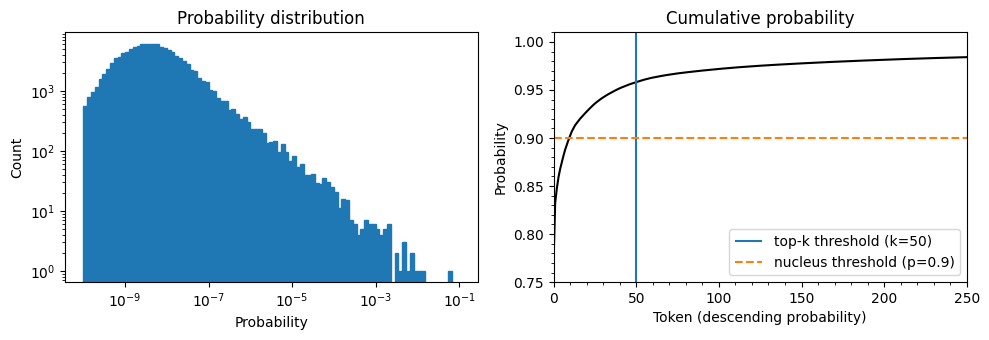

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(probs[0], bins=np.logspace(-10, -1, 100), color="C0", edgecolor="C0")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Probability distribution")
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("Count")
#axes[0].grid(which="major")

axes[1].plot(np.cumsum(np.sort(probs[0])[::-1]), color="black")
axes[1].set_xlim([0, 250])
axes[1].set_ylim([0.75, 1.01])
axes[1].set_title("Cumulative probability")
axes[1].set_ylabel("Probability")
axes[1].set_xlabel("Token (descending probability)")
#axes[1].grid(which="major")
axes[1].minorticks_on()
#axes[1].grid(which='minor', linewidth='0.5')
top_k_label = 'top-k threshold (k=50)'
top_p_label = 'nucleus threshold (p=0.9)'
axes[1].vlines(x=50, ymin=0, ymax=2, color='C0', label=top_k_label)
axes[1].hlines(y=0.9, xmin=0, xmax=250, color='C1', label=top_p_label, linestyle='--')
axes[1].legend(loc='lower right')
plt.tight_layout()

In [24]:
for model_name, bundle in models.items():
    print("="*100)
    print(f"Model: {model_name}. Default generation config:\n{model.generation_config}")
    
    model = bundle['model']
    tokenizer = bundle['tokenizer']

    if model.generation_config.top_k:
        default_k = model.generation_config.top_k
    else:
        default_k = 50
        print("Falling back to default top_k of 50")
    
    print('='*100 +'\n')

    for prompt in prompts:
        print(f"Prompt: {prompt}")
        print("-"*100)
        input_ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(model.device)
        input_len = input_ids.shape[-1]
    
        if input_len + MAX_NEW_TOKENS > bundle['max_context']:
            allowed_new = bundle['max_context'] - input_len
        else:
            allowed_new = MAX_NEW_TOKENS
            
        for k in [int(default_k*0.8), default_k, int(default_k*1.2)]:
            print(f"top_k: {k}")
            print('-'*100)
            
            starter = torch.cuda.Event(enable_timing=True)
            ender = torch.cuda.Event(enable_timing=True)
            torch.cuda.synchronize()
            starter.record()
            
            output = model.generate(input_ids, max_new_tokens=allowed_new, do_sample=True, top_k=k)
            
            ender.record()
            torch.cuda.synchronize()
        
            elapsed = starter.elapsed_time(ender) / 1000
            
            print(tokenizer.decode(output[0]))
            print(f"\nGenerate time: {elapsed:.2f}s\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2. Default generation config:
GenerationConfig {
  "bos_token_id": 128000,
  "do_sample": true,
  "eos_token_id": 128001,
  "max_length": 131072,
  "pad_token_id": 128004,
  "temperature": 0.6,
  "top_p": 0.9
}

Falling back to default top_k of 50

Prompt: The Implications of Recent Developments in Artificial Intelligence.
----------------------------------------------------------------------------------------------------
top_k: 40
----------------------------------------------------------------------------------------------------


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The Implications of Recent Developments in Artificial Intelligence. Theoretical and Applied Research, 21(1.), 5–40. doi:10.1177/1748-917X-2131-1 CrossRef Full Text | Google Scholar

H. Pöger, R. N. Weiburg, D. J. Dehn, C. H. Van Dijk, V. W. A. van den Broek, J. van der Waals, T. E. van der Kraek, E. Z. Van den Eijen, X. Li, K. Yang, M. Xu, Y. Yang, J. Li, Y. Yang, T. Yang, C. Z. Zhang, Y. Zhang, C. Z. Zhu, T. Wei, L. Zhang, T. Li, Y. Zhang, S. J. Lin, F. Zia, M. Wang, B. Hui.

Lao Zeng, F. Zhang, Jie Liu, and S. T. Huang. 2014. The influence of the LSTM on computational complexity: an alternative to an algorithm for high frequency computation. IEEE Theor., 59(4 Suppl.), 973-994. doi:10.1109/S00000443907010068 CrossRef Full Text | Google Scholar

B. Van Zandt, G. Sjou, and R. van Riet. 2006. Computational complexity for high-dimensional modeling: A theoretical and practical analysis. J. Comp. Neurol., 29, 4–20. doi:10.1111/j.1467-8207.2006.00236.x CrossRef Full Text | Google Scholar

Ch

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

<|begin_of_text|>The Implications of Recent Developments in Artificial Intelligence. A paper by the Center for the Study of Existential Risk
This is an excellent paper from the Center for the Study of Existential Risk. The paper is available at the link below.
http://www.cser.ac.uk/sites/www.cser.ac.uk/files/CSER%20Report%20-%20The%20Implications%20of%20Recent%20Developments%20in%20Artificial%20Intelligence.pdf
The following is an excerpt from the paper.
In this paper we review the most recent developments in AI, and consider their implications. We find that the current situation is more precarious than is generally recognised. We conclude that the existential risk posed by AI is no greater than that posed by other technologies that came before, such as nuclear weapons. However, we also conclude that the risk is substantial enough that a global discussion of the risks posed by AI should be initiated, and that the research program of the Center for the Study of Existential Risk should b

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|begin_of_text|>The recent advancements in artificial intelligence (AI) have  revolutionized the way we interact with technology. From voice assistants to self-driving cars, AI has become an integral part of our daily lives. However, the field of AI is not without its challenges. One of the most significant challenges is the lack of diversity in AI research and development. In this article, we will explore the reasons behind this lack of diversity and what can be done to address it.
The lack of diversity in AI research and development is a multifaceted problem. One of the main reasons for this is the homogeneity of the field. The majority of AI researchers are men, and the majority of them are from developed countries. This homogeneity leads to a lack of diverse perspectives and experiences in the field, which can result in biased algorithms and systems.
Another reason for the lack of diversity in AI is the lack of representation in the field. Women and minorities are underrepresented

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|begin_of_text|>The recent advancements in artificial intelligence (AI) have  revolutionized the way we interact with technology. From voice assistants to self-driving cars, AI has become an integral part of our daily lives. However, as AI continues to evolve, it’s important to consider the ethical implications of its development and deployment. One area where AI raises ethical concerns is in the field of data collection and analysis.
Data is the lifeblood of AI, and as more and more data is collected, it becomes easier for AI systems to learn and improve. However, there are ethical concerns surrounding the collection and use of this data. For example, companies may collect data on individuals without their knowledge or consent, or use data in ways that are discriminatory or harmful. Additionally, as AI systems become more sophisticated, they may be able to make decisions that have significant impacts on individuals or society as a whole, without the proper safeguards in place.
Anothe

In [25]:
for model_name, bundle in models.items():
    print("="*100)
    print(f"Model: {model_name}. Default generation config:\n{model.generation_config}")
    
    model = bundle['model']
    tokenizer = bundle['tokenizer']

    if model.generation_config.top_k:
        default_p = model.generation_config.top_p
    else:
        default_p = 1.0
        print("Falling back to default top_p of 1.0")
    
    print('='*100 +'\n')

    for prompt in prompts:
        print(f"Prompt: {prompt}")
        print("-"*100)
        input_ids = tokenizer(prompt, return_tensors='pt')['input_ids'].to(model.device)
        input_len = input_ids.shape[-1]
    
        if input_len + MAX_NEW_TOKENS > bundle['max_context']:
            allowed_new = bundle['max_context'] - input_len
        else:
            allowed_new = MAX_NEW_TOKENS
            
        for p in [0.8, 0.9, 1.0]:
            print(f"top_p: {p}")
            print('-'*100)
            
            starter = torch.cuda.Event(enable_timing=True)
            ender = torch.cuda.Event(enable_timing=True)
            torch.cuda.synchronize()
            starter.record()
            
            output = model.generate(input_ids, max_new_tokens=allowed_new, do_sample=True, top_p=p)
            
            ender.record()
            torch.cuda.synchronize()
        
            elapsed = starter.elapsed_time(ender) / 1000
            
            print(tokenizer.decode(output[0]))
            print(f"\nGenerate time: {elapsed:.2f}s\n")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Model: openai-community/gpt2. Default generation config:
GenerationConfig {
  "bos_token_id": 128000,
  "do_sample": true,
  "eos_token_id": 128001,
  "max_length": 131072,
  "pad_token_id": 128004,
  "temperature": 0.6,
  "top_p": 0.9
}

Falling back to default top_p of 1.0

Prompt: The Implications of Recent Developments in Artificial Intelligence.
----------------------------------------------------------------------------------------------------
top_p: 0.8
----------------------------------------------------------------------------------------------------


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The Implications of Recent Developments in Artificial Intelligence. PLoS ONE 5(9): e0117457. doi: 10.1371/journal.pone.0117457 Google Scholar Crossref, Medline, ISI

Rocha, E., Karp, M., Mennin, E., Noguchi, T., Hasegawa, H., & Gomi, Y. (2012). Understanding the neural architecture of neural activity and memory: an open-ended approach to the optimization of the learning curve. NeuroImage 2, 362–380. doi: 10.1016/j.neuroimage.2011.08.007 Google Scholar Crossref, Medline, ISI

Schaefer, M., Deutsch, K., & Bühl, R. (2007). The cognitive system and its application in neuroscience. Frontiers in neuroscience 2, 4. doi: 10.3389/fnhum.2007.0017 Google Scholar Crossref, Medline, ISI

Stroeve, R., Fuchs, K., & Vohra, S. (2006). The neural mechanisms of language processing: a meta-analysis. Cognitive Neurosciences 13, 1335–1347. doi: 10.1007/s00221-006-0015-0 Google Scholar Crossref, Medline, ISI

Swinberg, S., Oettinger, A., Schmeling, A., Ziel, A., Meehan, H., Soder, R., Schindler, A., & Schuma

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

<|begin_of_text|>The Implications of Recent Developments in Artificial Intelligence. A Discussion with Rodney Brooks
Rodney Brooks, founder of iRobot, Inc., and former director of the MIT Artificial Intelligence Laboratory, gave a talk this morning at the MIT Faculty Club. I went with a friend, who is a professor of mechanical engineering and who had worked with Brooks in the past, and we were both curious about his take on the state of AI. I was also interested in getting a sense of the current level of AI technology, as his talk was advertised as a discussion of recent developments in AI.
Brooks has been a major player in the field of AI, and his talk was fascinating. He is very much a hands-on engineer, and he began by showing us some of the robots he has built. They included a robot that could “walk” on a treadmill, and one that could autonomously navigate a room, avoid obstacles, and reach a target. These robots were impressive, and I was amazed at how quickly they could move arou

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|begin_of_text|>The recent advancements in artificial intelligence (AI) have  opened up a whole new world of possibilities for businesses. AI-powered chatbots are becoming increasingly popular as they provide businesses with a cost-effective way to interact with customers and provide support. However, with the increasing number of chatbots available, it can be difficult to know which one is the best fit for your business. In this article, we will explore the top 5 AI-powered chatbots for businesses in 2023.
ChatGPT is a language model developed by OpenAI that is capable of generating human-like text. It is trained on a large corpus of text data and is able to generate responses that are coherent and relevant to the input text. ChatGPT is a powerful tool for businesses looking to automate customer support and provide personalized responses to customers.
Google’s Dialogflow is a natural language understanding platform that allows businesses to build chatbots that can understand and resp

Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|begin_of_text|>The recent advancements in artificial intelligence (AI) have  revolutionized the field of digital marketing. AI-powered tools are becoming increasingly popular among marketers, offering unprecedented levels of efficiency and effectiveness in various aspects of digital marketing.
In this article, we will explore the top AI-powered tools for digital marketing, and discuss how they can help marketers achieve their goals in 2023.
AI-powered tools for digital marketing
ChatGPT: ChatGPT is an AI-powered chatbot that can generate human-like responses to customer queries. It is trained on a vast amount of data and can provide personalized responses to customers, making it an invaluable tool for customer support and engagement.
Google Ads: Google Ads is a popular pay-per-click (PPC) advertising platform that uses AI to optimize ad campaigns for maximum ROI. AI algorithms analyze user behavior and preferences to deliver targeted ads to the right audience, increasing the chances 

Top-k sampling restricts selection to the k most probable tokens, preventing low-probability tokens from being sampled. Nucleus sampling, top_p, selects the set of tokens whose cumulative probability meets a threshold p. Leaving aside model complexity considerations, both sampling methods seem to reduce the mechanical sounding nature observed earlier while top_p in the 0.9-1.0 range appears reasonably suited for the task.

### Qwen and Gemma model with refined prompt 

In [26]:
messages = [
    {
        'role': 'system',
        'content': (
            "You are a helpful assistant that writes clear, coherent short articles. "
            "Write in a neutral, informative tone. "
            "Produce one well-structured article only."
        )
    },
    {
        'role': 'user',
        'content': (
            "Write a short article titled 'The Implications of Recent Developments in Artificial Intelligence'. "
            "The article should be 4-6 paragraphs, coherent, and readable. "
            "Focus on practical, social, economic, and ethical implications."
        )
    },
]

#### Qwen/Qwen3-8B

In [27]:
unload_everything(models)

{'allocated_gb': 0.01,
 'reserved_gb': 0.02,
 'max_allocated_gb': 9.42,
 'max_reserved_gb': 10.01,
 'free_gb': 10.85,
 'total_gb': 11.62,
 'used_gb': 0.77}

In [28]:
models = OrderedDict()
model_paths = ["../Qwen-8B/"]

In [29]:
load_models(use_processor=True, return_context_len=False)

Loading: ../Qwen-8B/


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 399/399 [00:06<00:00, 61.35it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


Loaded ../Qwen-8B/ in 7.16s


{'allocated_gb': 8.36,
 'reserved_gb': 8.38,
 'max_allocated_gb': 9.42,
 'max_reserved_gb': 10.01,
 'free_gb': 2.5,
 'total_gb': 11.62,
 'used_gb': 9.12}

In [30]:
for model_name, bundle in models.items():
    print('='*100)

    model = bundle['model']
    processor = bundle['processor']

    print(f"Model: {model_name}. Default generation config:\n{model.generation_config}")
    print('='*100 +'\n')

Model: ../Qwen-8B/. Default generation config:
GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "temperature": 0.6,
  "top_k": 20,
  "top_p": 0.95
}




In [31]:
for model_name, bundle in models.items():
    print('='*100)

    model = bundle['model']
    processor = bundle['processor']

    print(f"Model: {model_name}")
    print('='*100 +'\n')
    
    text = processor.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True, 
        enable_thinking=False
    )

    inputs = processor(text=text, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[-1]

    default_config = model.generation_config
    custom_config = copy.deepcopy(model.generation_config)
    custom_config.temperature = 0.9
    custom_config.top_p = 0.95
    custom_config.top_k = 40
    
    for config in [default_config, custom_config]:
        print(config)
        print('-'*100)
        
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)

        torch.cuda.synchronize()
        starter.record()
        outputs = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, generation_config=config)
        ender.record()
        torch.cuda.synchronize()

        elapsed = starter.elapsed_time(ender) / 1000

        response = processor.decode(outputs[0][input_len:], skip_special_tokens=True)
        
        try:
            print(processor.parse_response(response)['content'])
        except AttributeError:
            print(response)
            
        print(f"\nGenerate time: {elapsed:.2f}s\n")

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Model: ../Qwen-8B/

GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "temperature": 0.6,
  "top_k": 20,
  "top_p": 0.95
}

----------------------------------------------------------------------------------------------------
**The Implications of Recent Developments in Artificial Intelligence**

Recent advancements in artificial intelligence (AI) have significantly expanded the capabilities of machine learning models, enabling them to perform complex tasks with increasing accuracy and efficiency. These developments have led to breakthroughs in natural language processing, computer vision, and predictive analytics, which are now being integrated into a wide range of industries. As AI systems become more sophisticated, their practical applications are reshaping how businesses operate and how individuals interact with technology.

One of the most notable practical implications of AI is its growing 

#### google/gemma-4-E4B-it

In [32]:
unload_everything(models)

{'allocated_gb': 0.01,
 'reserved_gb': 0.02,
 'max_allocated_gb': 9.64,
 'max_reserved_gb': 10.71,
 'free_gb': 10.85,
 'total_gb': 11.62,
 'used_gb': 0.77}

In [33]:
models = OrderedDict()
model_paths = ["google/gemma-4-E4B-it"]

In [34]:
load_models(use_processor=True, return_context_len=False)

Loading: google/gemma-4-E4B-it


Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2130/2130 [00:03<00:00, 568.75it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


Loaded google/gemma-4-E4B-it in 9.88s


{'allocated_gb': 4.45,
 'reserved_gb': 4.47,
 'max_allocated_gb': 9.64,
 'max_reserved_gb': 10.71,
 'free_gb': 6.41,
 'total_gb': 11.62,
 'used_gb': 5.21}

In [35]:
for model_name, bundle in models.items():
    print('='*100)

    model = bundle['model']
    processor = bundle['processor']

    print(f"Model: {model_name}. Default generation config:\n{model.generation_config}")
    print('='*100 +'\n')

Model: google/gemma-4-E4B-it. Default generation config:
GenerationConfig {
  "bos_token_id": 2,
  "do_sample": true,
  "eos_token_id": [
    1,
    106,
    50
  ],
  "pad_token_id": 0,
  "temperature": 1.0,
  "top_k": 64,
  "top_p": 0.95
}




In [36]:
for model_name, bundle in models.items():
    print('='*100)

    model = bundle['model']
    processor = bundle['processor']

    print(f"Model: {model_name}")
    print('='*100 +'\n')
    
    text = processor.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True, 
        enable_thinking=False
    )

    inputs = processor(text=text, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[-1]

    default_config = model.generation_config
    custom_config = copy.deepcopy(model.generation_config)
    custom_config.temperature = 0.9
    custom_config.top_p = 0.95
    custom_config.top_k = 40
    
    for config in [default_config, custom_config]:
        print(config)
        print('-'*100)
        
        starter = torch.cuda.Event(enable_timing=True)
        ender = torch.cuda.Event(enable_timing=True)

        torch.cuda.synchronize()
        starter.record()
        outputs = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, generation_config=config)
        ender.record()
        torch.cuda.synchronize()

        elapsed = starter.elapsed_time(ender) / 1000

        response = processor.decode(outputs[0][input_len:], skip_special_tokens=True)
        
        try:
            print(processor.parse_response(response)['content'])
        except AttributeError:
            print(response)
            
        print(f"\nGenerate time: {elapsed:.2f}s\n")

Model: google/gemma-4-E4B-it

GenerationConfig {
  "bos_token_id": 2,
  "do_sample": true,
  "eos_token_id": [
    1,
    106,
    50
  ],
  "pad_token_id": 0,
  "temperature": 1.0,
  "top_k": 64,
  "top_p": 0.95
}

----------------------------------------------------------------------------------------------------
## The Implications of Recent Developments in Artificial Intelligence

Recent advancements in Artificial Intelligence (AI) have moved the technology from the realm of science fiction into the fabric of daily life. Sophisticated large language models, advanced computer vision, and accelerated machine learning capabilities are reshaping industries and challenging established norms. These developments are not merely incremental upgrades; they represent fundamental shifts with profound practical, social, economic, and ethical implications that society is only beginning to navigate.

Economically, the impact of advanced AI is characterized by significant productivity gains and wo

As immediately apparent from both models above, the structured user and system prompts provided and the clear improvement in model capacity produced much more coherent and balanced output.  Gemma-4-E4B-it with nucleus sampling (top-p=0.95, top-k=40, temperature=0.9) and a structured prompt produced the most human-like, factually grounded article in my opinion, although the quality of all four iterations is impressive. Model capacity and prompt structuring are the dominant factors in output quality from what I have observed.